# Class 15 non-inertial-frame experiment 3

This notebook loads the second trajectory exported from Tracker and plots the measured path on a circular coordinate grid. Position units are centimeters.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

data_path = Path("Class15_experiment_3.txt")
data = np.loadtxt(data_path, skiprows=2)

t_s = data[:, 0]
x_cm = data[:, 1]
y_cm = data[:, 2]

print(f"Loaded {len(t_s)} points from {data_path}")
print(f"Time interval: {t_s[0]:.3f} to {t_s[-1]:.3f} s")
print(f"Initial point: ({x_cm[0]:.3f}, {y_cm[0]:.3f}) cm")
print(f"Final point:   ({x_cm[-1]:.3f}, {y_cm[-1]:.3f}) cm")

Loaded 13 points from Class15_experiment_3.txt
Time interval: 0.440 to 0.968 s
Initial point: (-2.488, 3.463) cm
Final point:   (1.561, 3.804) cm


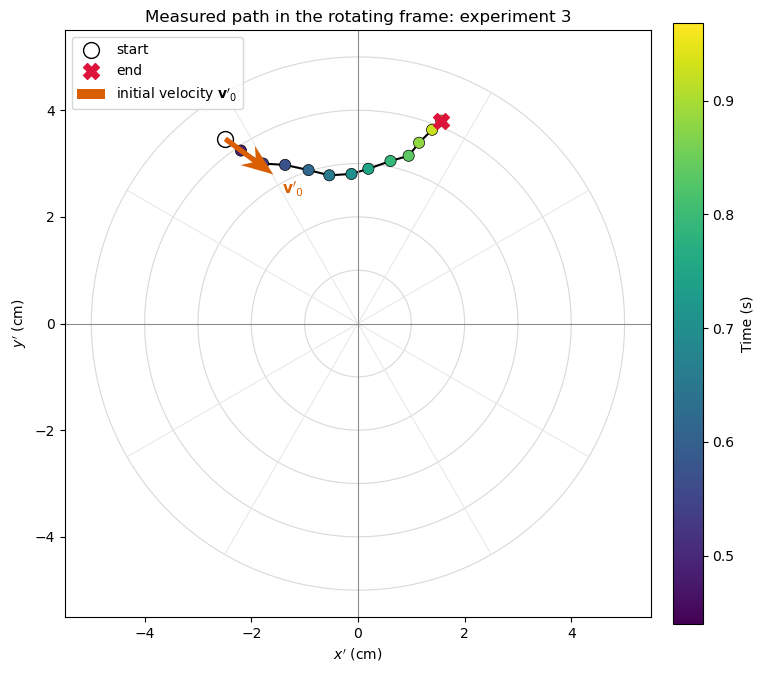

In [2]:
# Estimate the initial velocity for the arrow with a constrained six-point quadratic fit.
tau_s = t_s - t_s[0]
n_fit_arrow = 6
tau_arrow = tau_s[:n_fit_arrow]
arrow_design = np.column_stack((tau_arrow[1:], 0.5 * tau_arrow[1:]**2))
vx0_arrow, _ = np.linalg.lstsq(
    arrow_design, x_cm[1:n_fit_arrow] - x_cm[0], rcond=None
)[0]
vy0_arrow, _ = np.linalg.lstsq(
    arrow_design, y_cm[1:n_fit_arrow] - y_cm[0], rcond=None
)[0]

radius_cm = np.hypot(x_cm, y_cm)
plot_radius_cm = np.ceil(radius_cm.max())

fig, ax = plt.subplots(figsize=(8, 8))

# Circular grid rings centered on the rotating-frame origin
theta = np.linspace(0, 2 * np.pi, 500)
for radius in np.arange(1, plot_radius_cm + 1):
    ax.plot(
        radius * np.cos(theta),
        radius * np.sin(theta),
        color="0.85",
        linewidth=0.8,
        zorder=0,
    )

# Radial guides every 30 degrees
for angle in np.deg2rad(np.arange(0, 360, 30)):
    ax.plot(
        [0, plot_radius_cm * np.cos(angle)],
        [0, plot_radius_cm * np.sin(angle)],
        color="0.90",
        linewidth=0.7,
        zorder=0,
    )

points = ax.scatter(
    x_cm,
    y_cm,
    c=t_s,
    cmap="viridis",
    s=65,
    edgecolor="black",
    linewidth=0.5,
    zorder=3,
)
ax.plot(x_cm, y_cm, color="black", linewidth=1.5, zorder=2)
ax.scatter(
    x_cm[0], y_cm[0], marker="o", s=130, facecolor="white",
    edgecolor="black", label="start", zorder=4
)
ax.scatter(
    x_cm[-1], y_cm[-1], marker="X", s=130, color="crimson",
    label="end", zorder=4
)

# Initial-velocity vector; 0.12 s converts velocity to a readable displacement arrow.
arrow_dt_s = 0.12
ax.quiver(
    x_cm[0], y_cm[0],
    vx0_arrow * arrow_dt_s, vy0_arrow * arrow_dt_s,
    angles="xy", scale_units="xy", scale=1,
    color="#d95f02", width=0.009, headwidth=4.5, headlength=6,
    zorder=5, label=r"initial velocity $\mathbf{v}'_0$",
)
ax.annotate(
    r"$\mathbf{v}'_0$",
    (x_cm[0] + vx0_arrow * arrow_dt_s, y_cm[0] + vy0_arrow * arrow_dt_s),
    xytext=(6, -14), textcoords="offset points",
    color="#d95f02", fontsize=11, fontweight="bold",
)

limit = plot_radius_cm + 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal", adjustable="box")
ax.axhline(0, color="0.55", linewidth=0.8)
ax.axvline(0, color="0.55", linewidth=0.8)
ax.set_xlabel("$x'$ (cm)")
ax.set_ylabel("$y'$ (cm)")
ax.set_title("Measured path in the rotating frame: experiment 3")
ax.legend(loc="upper left")
colorbar = fig.colorbar(points, ax=ax, shrink=0.78, pad=0.03)
colorbar.set_label("Time (s)")
fig.tight_layout()
plt.show()

## Estimate the initial conditions

The Tracker timestamps begin at $t=0.440\,\mathrm{s}$, so define elapsed time $\tau=t-t_0$. Take the first measured point as the initial position. Estimate the velocity from a local quadratic fitted to the first six measurements (through $\tau=0.220\,\mathrm{s}$), constrained to pass through that first point:

$$q(\tau)-q(0)=v_{q,0}\tau+\tfrac12a_{q,0}\tau^2,\qquad q=x',y'.$$

The coefficient of $\tau$ is the initial-velocity estimate.

In [3]:
tau_s = t_s - t_s[0]
n_fit = 6
tau_fit = tau_s[:n_fit]
design = np.column_stack((tau_fit[1:], 0.5 * tau_fit[1:]**2))

vx0_cm_s, ax0_cm_s2 = np.linalg.lstsq(
    design, x_cm[1:n_fit] - x_cm[0], rcond=None
)[0]
vy0_cm_s, ay0_cm_s2 = np.linalg.lstsq(
    design, y_cm[1:n_fit] - y_cm[0], rcond=None
)[0]
x0_cm, y0_cm = x_cm[0], y_cm[0]

print("Estimated rotating-frame initial conditions")
print(f"Tracker start time t0 = {t_s[0]:.3f} s")
print(f"x'(t0)  = {x0_cm:7.3f} cm")
print(f"y'(t0)  = {y0_cm:7.3f} cm")
print(f"vx'(t0) = {vx0_cm_s:7.3f} cm/s")
print(f"vy'(t0) = {vy0_cm_s:7.3f} cm/s")
print(f"Local-fit accelerations: ax'(t0) = {ax0_cm_s2:.2f} cm/s², "
      f"ay'(t0) = {ay0_cm_s2:.2f} cm/s²")

Estimated rotating-frame initial conditions
Tracker start time t0 = 0.440 s
x'(t0)  =  -2.488 cm
y'(t0)  =   3.463 cm
vx'(t0) =   7.498 cm/s
vy'(t0) =  -5.550 cm/s
Local-fit accelerations: ax'(t0) = 13.45 cm/s², ay'(t0) = 23.26 cm/s²


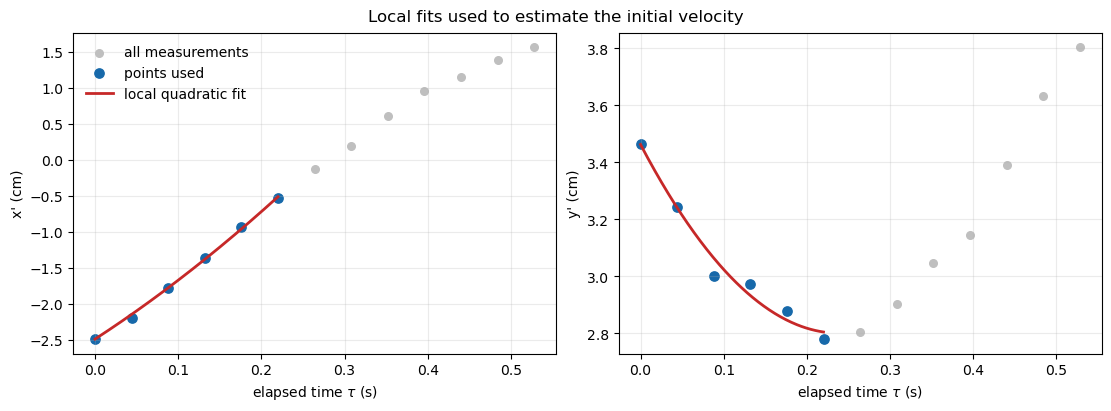

In [4]:
tau_smooth = np.linspace(0, tau_fit[-1], 200)
x_local = x0_cm + vx0_cm_s * tau_smooth + 0.5 * ax0_cm_s2 * tau_smooth**2
y_local = y0_cm + vy0_cm_s * tau_smooth + 0.5 * ay0_cm_s2 * tau_smooth**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, measured, fitted, label in [
    (axes[0], x_cm, x_local, "x'"),
    (axes[1], y_cm, y_local, "y'"),
]:
    ax.scatter(tau_s, measured, color="0.75", s=30, label="all measurements")
    ax.scatter(tau_fit, measured[:n_fit], color="#1769aa", s=45, label="points used")
    ax.plot(tau_smooth, fitted, color="#c62828", linewidth=2, label="local quadratic fit")
    ax.set_xlabel(r"elapsed time $\tau$ (s)")
    ax.set_ylabel(f"{label} (cm)")
    ax.grid(alpha=0.25)
axes[0].legend(frameon=False)
fig.suptitle("Local fits used to estimate the initial velocity")
plt.show()

In [5]:
window_results = []
for n_window in (5, 6, 7):
    tau_window = tau_s[:n_window]
    design_window = np.column_stack((tau_window[1:], 0.5 * tau_window[1:]**2))
    vx_window = np.linalg.lstsq(
        design_window, x_cm[1:n_window] - x_cm[0], rcond=None
    )[0][0]
    vy_window = np.linalg.lstsq(
        design_window, y_cm[1:n_window] - y_cm[0], rcond=None
    )[0][0]
    window_results.append((n_window, tau_window[-1], vx_window, vy_window))

print("points   tau_max (s)   vx'(t0) (cm/s)   vy'(t0) (cm/s)")
for n_window, tau_max, vx_window, vy_window in window_results:
    print(f"{n_window:>4d}       {tau_max:6.3f}         {vx_window:8.3f}          {vy_window:8.3f}")
velocity_samples = np.array([[row[2], row[3]] for row in window_results])
print("\nWindow sensitivity (sample standard deviation):")
print(f"vx'(t0): {velocity_samples[:, 0].std(ddof=1):.3f} cm/s")
print(f"vy'(t0): {velocity_samples[:, 1].std(ddof=1):.3f} cm/s")

points   tau_max (s)   vx'(t0) (cm/s)   vy'(t0) (cm/s)
   5        0.176            6.856            -6.219
   6        0.220            7.498            -5.550
   7        0.264            7.829            -5.536

Window sensitivity (sample standard deviation):
vx'(t0): 0.495 cm/s
vy'(t0): 0.390 cm/s


### Initial-condition estimate for the equations of motion

At the first tracked frame, $t_0=0.440\,\mathrm{s}$,

$$\boxed{(x'_0,y'_0)=(-2.488,3.463)\ \mathrm{cm}}$$

$$\boxed{(\dot{x}'_0,\dot{y}'_0)\approx(7.50,-5.55)\ \mathrm{cm/s}}.$$

Changing the fit from five to seven early-time points gives a sample standard deviation of about $0.49\,\mathrm{cm/s}$ in $\dot{x}'_0$ and $0.39\,\mathrm{cm/s}$ in $\dot{y}'_0$. This measures fitting-window sensitivity, not the full experimental uncertainty.